In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra, StatsBase;

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [127]:
ndimage = pyimport("scipy.ndimage") 

PyObject <module 'scipy.ndimage' from '/home/gridsan/aligho/.local/lib/python3.8/site-packages/scipy/ndimage/__init__.py'>

In [79]:
Energies = zeros(10, 10)
for i in 0:9
    for j in 0:9
        try
        Energies[i+1, j+1] = list_energy("Moire-$i-$j.out")
        catch e
            println("File Not Found")
        end
    end
end

In [80]:
findall(e->iszero(e), Energies)

CartesianIndex{2}[]

In [81]:
Energies[9, 3] 

-10242.25302945121

In [82]:
v1, v2, v3 = loadlattice("Moire-1-1.out");

In [83]:
det(hcat(v1, v2, v3))/sqrt(sum(v3.*v3))/13/1.44/1.44/3*2/sqrt(3)

-1.00604378745101

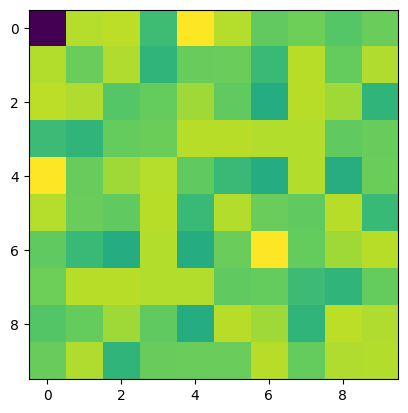

PyObject <matplotlib.image.AxesImage object at 0x7fb5a944caf0>

In [98]:
imshow(log.( Energies .- minimum(Energies) .+ 0.001))

In [97]:
Energies[10, 6] = Energies[10, 5]

-10242.25632315161

In [332]:
lattice_to_cartesian = hcat(v1[1:2], v2[1:2])/sqrt(sum(v1.*v1))*225/10

2×2 Matrix{Float64}:
 21.8413   -15.6009
 -5.40432  -16.213

In [333]:
cartesian_to_lattice = inv(lattice_to_cartesian)

2×2 Matrix{Float64}:
  0.03698    -0.0355839
 -0.0123266  -0.0498176

In [334]:
zEnergies=zscore(Energies)

10×10 Matrix{Float64}:
 -3.00785    0.92138    1.12187   …  -0.272245  -0.647685  -0.348773
  0.911753  -0.353384   0.846985      0.985699  -0.393816   0.849718
  1.11236    0.848238  -0.655098      1.01548    0.575512  -1.22797
 -1.01047   -1.23124   -0.40534       0.903602  -0.47511   -0.383781
  2.66347   -0.388505   0.56454       0.900034  -1.4296    -0.319672
  0.9202    -0.326455  -0.483782  …  -0.487194   1.00939   -1.07422
 -0.4694    -1.07563   -1.43409      -0.399692   0.564038   0.98143
 -0.282093   0.981368   1.01435      -1.01859   -1.23945   -0.399945
 -0.65752   -0.397792   0.573853     -1.23752    1.11031    0.84486
 -0.358626   0.850703  -1.22627      -0.403762   0.846083   0.914726

In [335]:
function returnE(x::Vector{<:Real})
    i, j = Int.(round.(cartesian_to_lattice*x)) 
    i, j = rem.([i, j], 10)
    i < 0 && (i = i+10)
    j < 0 && (j = j+10)
   #(i==0 && j==0) &&  println(i, " ", j)

    return (zEnergies[i+1, j+1])
end

returnE (generic function with 1 method)

In [365]:
N=800
EnergyArray = zeros(N, N)
for i in 1:N
    for j in 1:N
        r=[i, j] -[35, 0]
        EnergyArray[i, j] = returnE(r)
        #EnergyArray[i, j]  = log(returnE([i, j]) - minimum(Energies) .+ 0.1)
    end
end

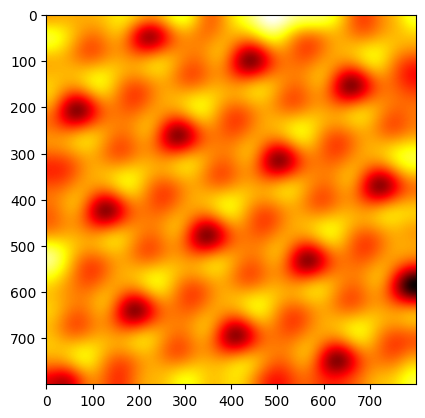

PyObject <matplotlib.image.AxesImage object at 0x7fb5a4a520a0>

In [376]:
img = ndimage.minimum_filter(np.rot90(EnergyArray), size=20)

img = ndimage.gaussian_filter(img, sigma=30)

imshow(img, cmap="hot", interpolation="gaussian")

In [371]:
Moire_Fig = imread("Moire13.jpg");

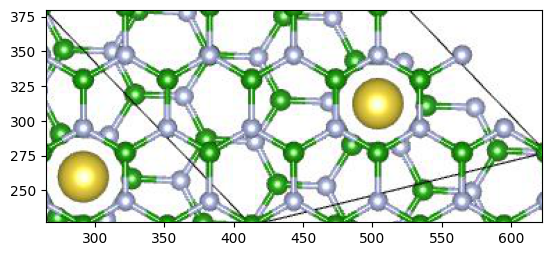

(265.0, 622.0)

In [372]:
imshow(Moire_Fig)
ylim(227, 380)
xlim(265, 622)

In [313]:
sqrt((380-227)^2+(622-265)^2)/sqrt(3)

224.24540129063965

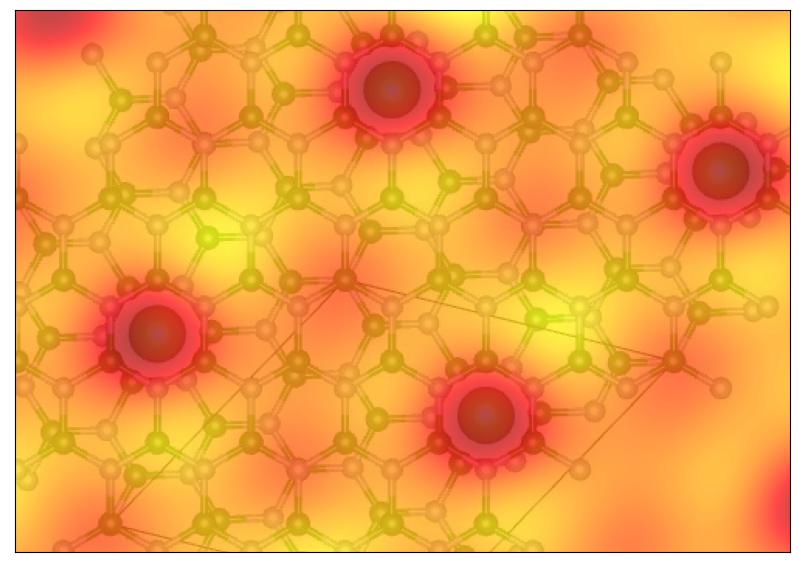

(Any[], Any[])

In [380]:
figure(figsize=(10, 10))
imshow(img, cmap="hot", interpolation="gaussian", alpha=0.9)
imshow(Moire_Fig, alpha=0.2)
xlim(200, 700)
ylim(400, 50)
xticks(Float64[])
yticks(Float64[])